# U-Net Segmentation for IDRiD Lesion Detection

This notebook trains a U-Net model for multi-label segmentation of retinal lesions (microaneurysms, haemorrhages, exudates, optic disc) on IDRiD dataset.

**Designed for local MacBook Pro execution (MPS/CPU support)**


In [1]:
# === Installation Block ===
# Install all required dependencies

%pip install -q torch torchvision torchaudio
%pip install -q albumentations==1.0.0
%pip install -q opencv-python
%pip install -q wandb
%pip install -q matplotlib
%pip install -q pillow
%pip install -q numpy

print("✓ All dependencies installed!")


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✓ All dependencies installed!


# === Section: Imports & Setup ===


In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import wandb

# Device configuration (LOCAL MACBOOK, NOT COLAB)
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"  # Apple Metal backend
else:
    device = "cpu"
print(f"Device: {device}")

# Image dimensions
IMG_HEIGHT = 256
IMG_WIDTH = 256

Device: mps


In [3]:

DATA_ROOT = "../data"  # Root data directory containing both aptos and idrid

IDRID_SEG_ROOT = f"{DATA_ROOT}/idrid/A. Segmentation"
IDRID_IMAGE_DIR = f"{IDRID_SEG_ROOT}/1. Original Images/a. Training Set"
IDRID_SEG_GT_ROOT = f"{IDRID_SEG_ROOT}/2. All Segmentation Groundtruths/a. Training Set"

IDRID_MASKS_DIRS = {
    "ma": f"{IDRID_SEG_GT_ROOT}/1. Microaneurysms",
    "he": f"{IDRID_SEG_GT_ROOT}/2. Haemorrhages",
    "ex_hard": f"{IDRID_SEG_GT_ROOT}/3. Hard Exudates",
    "ex_soft": f"{IDRID_SEG_GT_ROOT}/4. Soft Exudates",
    "od": f"{IDRID_SEG_GT_ROOT}/5. Optic Disc",
}

# Verify paths exist - fail loudly if data is not available
if not os.path.exists(DATA_ROOT):
    raise FileNotFoundError(f"DATA_ROOT does not exist: {DATA_ROOT}\n"
                          f"Please ensure the data is available at this location.")
if not os.path.exists(IDRID_IMAGE_DIR):
    raise FileNotFoundError(f"IDRiD image directory does not exist: {IDRID_IMAGE_DIR}\n"
                          f"Please ensure the data is available at this location.")
if not os.path.exists(IDRID_SEG_GT_ROOT):
    raise FileNotFoundError(f"IDRiD ground truth directory does not exist: {IDRID_SEG_GT_ROOT}\n"
                          f"Please ensure the data is available at this location.")

print(f"✓ Data paths verified")
print(f"  Image directory: {IDRID_IMAGE_DIR}")
print(f"  Ground truth directory: {IDRID_SEG_GT_ROOT}")
print(f"  Number of lesion types: {len(IDRID_MASKS_DIRS)}")


✓ Data paths verified
  Image directory: ../data/idrid/A. Segmentation/1. Original Images/a. Training Set
  Ground truth directory: ../data/idrid/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set
  Number of lesion types: 5


# === Section: Dataset & Albumentations ===


In [4]:
# Scan IDRiD directories and build list of image IDs
def get_idrid_image_ids(image_dir, mask_dirs):
    """
    Find all image IDs that have:
    - One RGB fundus image
    - Masks for all lesion types
    """
    # Get all image files (assuming .jpg or .png)
    image_files = []
    for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
        image_files.extend([f for f in os.listdir(image_dir) if f.endswith(ext)])
    
    image_ids = []
    lesion_types = list(mask_dirs.keys())
    
    for img_file in image_files:
        # Extract image ID (remove extension)
        img_id = os.path.splitext(img_file)[0]
        
        # Check if all masks exist for this image ID
        all_masks_exist = True
        for lesion_type in lesion_types:
            mask_dir = mask_dirs[lesion_type]
            # Mask files might have different naming conventions
            # Try common patterns: {img_id}.tif, {img_id}_{lesion_type}.tif, etc.
            mask_patterns = [
                f"{img_id}.tif",
                f"{img_id}.png",
                f"{img_id}.jpg",
                f"{img_id}_{lesion_type}.tif",
                f"{img_id}_{lesion_type}.png",
            ]
            
            mask_found = False
            if os.path.exists(mask_dir):
                for pattern in mask_patterns:
                    if os.path.exists(os.path.join(mask_dir, pattern)):
                        mask_found = True
                        break
                if not mask_found:
                    # Try listing directory and finding matching files
                    if os.path.exists(mask_dir):
                        mask_files = os.listdir(mask_dir)
                        # Check if any file starts with img_id
                        for mf in mask_files:
                            if mf.startswith(img_id) or img_id in mf:
                                mask_found = True
                                break
            
            if not mask_found:
                all_masks_exist = False
                break
        
        if all_masks_exist:
            image_ids.append(img_id)
    
    return sorted(image_ids)

# Get image IDs
image_ids = get_idrid_image_ids(IDRID_IMAGE_DIR, IDRID_MASKS_DIRS)
print(f"Found {len(image_ids)} images with all masks")
print(f"First 5 image IDs: {image_ids[:5]}")


Found 26 images with all masks
First 5 image IDs: ['IDRiD_03', 'IDRiD_08', 'IDRiD_13', 'IDRiD_14', 'IDRiD_17']


In [5]:
class IDRiDDataset(Dataset):
    """
    Dataset for IDRiD segmentation with multi-label masks.
    Each sample returns:
    - image: (3, H, W) float32 tensor, normalized
    - mask: (num_classes, H, W) float32 tensor with binary masks
    """
    def __init__(self, image_ids, image_dir, mask_dirs, transform=None):
        self.image_ids = image_ids
        self.image_dir = image_dir
        self.mask_dirs = mask_dirs
        self.transform = transform
        self.lesion_types = list(mask_dirs.keys())
        self.num_classes = len(self.lesion_types)
    
    def __len__(self):
        return len(self.image_ids)
    
    def _find_mask_file(self, mask_dir, img_id):
        """Find mask file for given image ID in mask directory."""
        if not os.path.exists(mask_dir):
            return None
        
        # Try common patterns
        patterns = [
            f"{img_id}.tif",
            f"{img_id}.png",
            f"{img_id}.jpg",
            f"{img_id}.TIF",
            f"{img_id}.PNG",
            f"{img_id}.JPG",
        ]
        
        for pattern in patterns:
            mask_path = os.path.join(mask_dir, pattern)
            if os.path.exists(mask_path):
                return mask_path
        
        # Try listing and matching
        mask_files = os.listdir(mask_dir)
        for mf in mask_files:
            if img_id in mf or mf.startswith(img_id):
                return os.path.join(mask_dir, mf)
        
        return None
    
    def _load_mask(self, mask_path):
        """Load mask and convert to binary {0, 1}."""
        if mask_path is None or not os.path.exists(mask_path):
            return None
        
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            return None
        
        # Convert to binary: normalize to [0, 1] and threshold
        mask = mask.astype(np.float32) / 255.0
        mask = (mask > 0.5).astype(np.float32)
        
        return mask
    
    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        
        # Load RGB image
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            candidate = os.path.join(self.image_dir, f"{img_id}{ext}")
            if os.path.exists(candidate):
                img_path = candidate
                break
        
        if img_path is None:
            raise FileNotFoundError(f"Image not found for ID: {img_id}")
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # BGR -> RGB
        
        # Load all masks
        masks = []
        for lesion_type in self.lesion_types:
            mask_dir = self.mask_dirs[lesion_type]
            mask_path = self._find_mask_file(mask_dir, img_id)
            mask = self._load_mask(mask_path)
            
            if mask is None:
                # If mask not found, create zero mask
                mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)
            
            masks.append(mask)
        
        # Stack masks: (num_classes, H, W)
        mask_stack = np.stack(masks, axis=0)  # Shape: (num_classes, H, W)
        
        # Apply transforms (Albumentations expects masks as a list of (H, W) arrays)
        if self.transform:
            # Pass masks as a list of (H, W) arrays
            mask_list = [mask_stack[i] for i in range(mask_stack.shape[0])]
            
            transformed = self.transform(image=image, masks=mask_list)
            image = transformed['image']
            mask_list = transformed['masks']
            
            # Stack masks back: handle both numpy arrays and tensors (after ToTensorV2)
            if isinstance(mask_list[0], torch.Tensor):
                # If ToTensorV2 was applied, masks are tensors
                mask_stack = torch.stack(mask_list, dim=0).float()
            else:
                # If not, stack as numpy then convert
                mask_stack = np.stack(mask_list, axis=0).astype(np.float32)
                mask_stack = torch.from_numpy(mask_stack).float()
        else:
            # No transform: convert to tensor
            mask_stack = torch.from_numpy(mask_stack).float()
        
        # Image is already a tensor after ToTensorV2, or needs conversion
        if not isinstance(image, torch.Tensor):
            # If image is (H, W, C), transpose to (C, H, W)
            if len(image.shape) == 3 and image.shape[2] == 3:
                image = image.transpose(2, 0, 1)
            image = torch.from_numpy(image).float()
        
        return image, mask_stack


In [6]:
# Train transforms – keep aspect ratio, then pad to square so fundus stays round
train_transform = A.Compose([
    # Resize the longest side to IMG_HEIGHT/IMG_WIDTH but keep aspect ratio
    A.LongestMaxSize(max_size=min(IMG_HEIGHT, IMG_WIDTH)),

    # Pad the shorter side so final size is exactly (IMG_HEIGHT, IMG_WIDTH)
    A.PadIfNeeded(
        min_height=IMG_HEIGHT,
        min_width=IMG_WIDTH,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,        # black padding for image
        mask_value=0    # 0 for masks (background)
    ),

    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        p=0.5,
        border_mode=cv2.BORDER_REFLECT_101
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.3
    ),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])

# Val/Test transforms – same “keep circle round” logic
val_transform = A.Compose([
    A.LongestMaxSize(max_size=min(IMG_HEIGHT, IMG_WIDTH)),
    A.PadIfNeeded(
        min_height=IMG_HEIGHT,
        min_width=IMG_WIDTH,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        mask_value=0
    ),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2()
])


In [7]:
# Split train/val (80/20)
split_idx = int(0.8 * len(image_ids))
train_ids = sorted(image_ids[:split_idx])
val_ids = sorted(image_ids[split_idx:])

print(f"Train: {len(train_ids)} images")
print(f"Val: {len(val_ids)} images")

# Create datasets
train_dataset = IDRiDDataset(train_ids, IDRID_IMAGE_DIR, IDRID_MASKS_DIRS, transform=train_transform)
val_dataset = IDRiDDataset(val_ids, IDRID_IMAGE_DIR, IDRID_MASKS_DIRS, transform=val_transform)

# Create dataloaders (small batch sizes for Mac)
BATCH_SIZE = 4  # Adjust based on your Mac's memory
NUM_WORKERS = 0  # Use 0 for Mac notebooks to avoid issues

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False  # MPS doesn't support pin_memory
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

print(f"✓ Datasets and DataLoaders created")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Number of classes: {len(IDRID_MASKS_DIRS)}")


Train: 20 images
Val: 6 images
✓ Datasets and DataLoaders created
  Batch size: 4
  Number of classes: 5


Visualizing training samples...


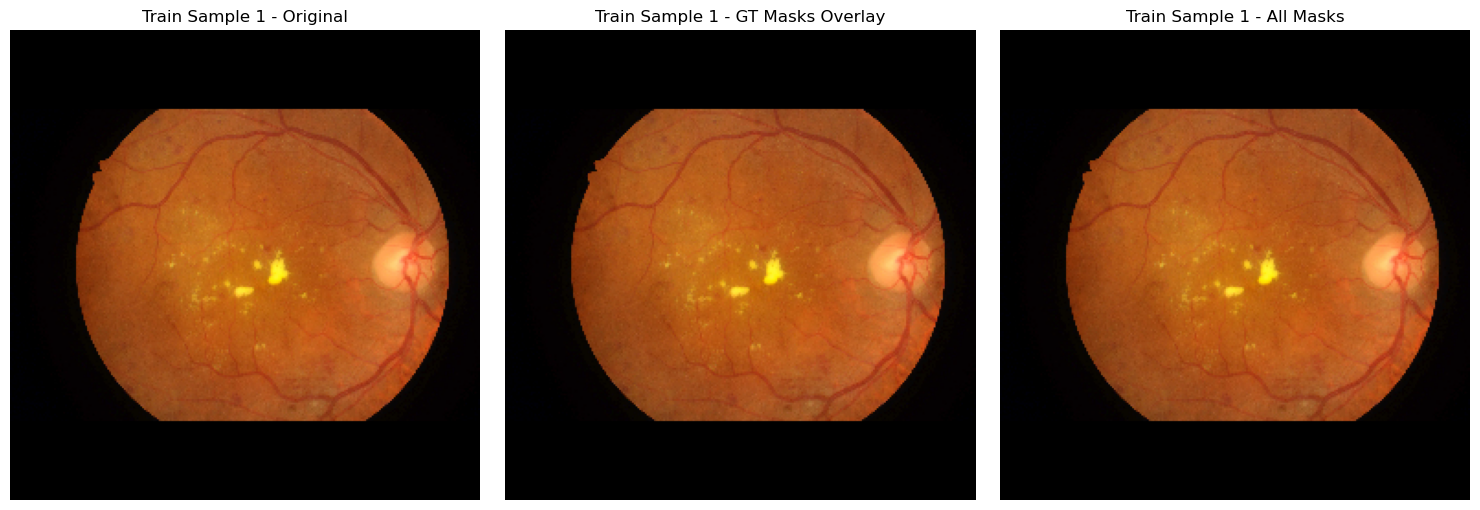

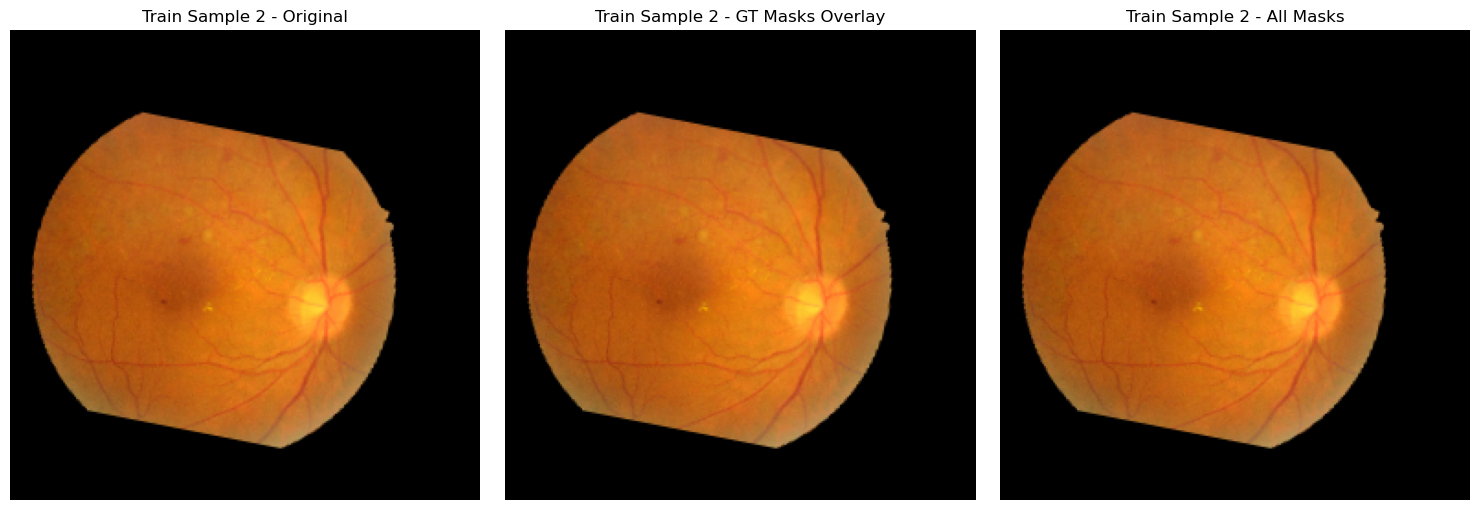

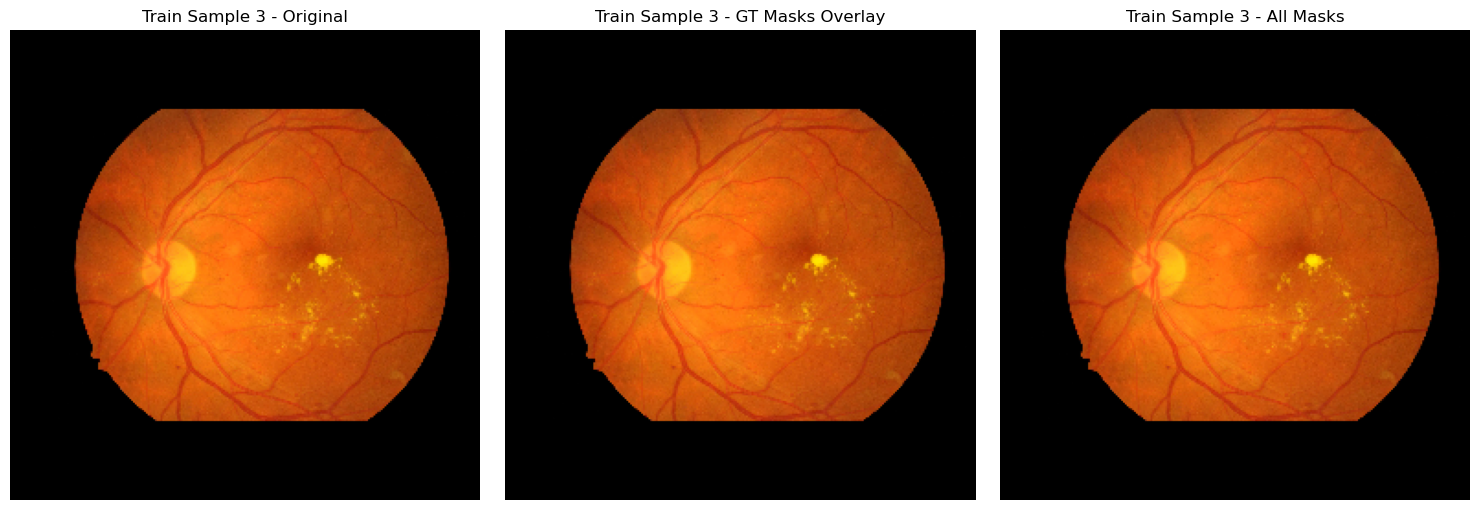

In [8]:
# Sanity check: visualize a few samples
def visualize_sample(image, mask, lesion_types, title="Sample"):
    """Visualize image with overlaid masks."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Convert image tensor to numpy for display
    if isinstance(image, torch.Tensor):
        img_np = image.cpu().numpy()
        if img_np.shape[0] == 3:  # (C, H, W)
            img_np = img_np.transpose(1, 2, 0)
        # Denormalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = img_np * std + mean
        img_np = np.clip(img_np, 0, 1)
    else:
        img_np = image
    
    # Original image
    axes[0].imshow(img_np)
    axes[0].set_title(f"{title} - Original")
    axes[0].axis('off')
    
    # Ground truth masks overlay
    mask_np = mask.cpu().numpy() if isinstance(mask, torch.Tensor) else mask
    overlay = img_np.copy()
    
    # Color coding: ma=red, he=green, ex_hard=yellow, ex_soft=cyan, od=magenta
    colors = {
        'ma': [1, 0, 0],      # Red
        'he': [0, 1, 0],      # Green
        'ex_hard': [1, 1, 0], # Yellow
        'ex_soft': [0, 1, 1], # Cyan
        'od': [1, 0, 1]       # Magenta
    }
    
    for i, lesion_type in enumerate(lesion_types):
        if i < mask_np.shape[0]:
            mask_channel = mask_np[i]
            color = colors.get(lesion_type, [1, 1, 1])
            overlay[mask_channel > 0.5] = np.array(color)
    
    axes[1].imshow(overlay)
    axes[1].set_title(f"{title} - GT Masks Overlay")
    axes[1].axis('off')
    
    # Individual masks grid
    num_masks = mask_np.shape[0]
    axes[2].imshow(img_np)
    axes[2].set_title(f"{title} - All Masks")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Get a few samples
print("Visualizing training samples...")
for i in range(min(3, len(train_dataset))):
    image, mask = train_dataset[i]
    visualize_sample(image, mask, list(IDRID_MASKS_DIRS.keys()), title=f"Train Sample {i+1}")


# === Section: U-Net Model ===


In [9]:
class UNet(nn.Module):
    """
    U-Net for multi-label segmentation.
    Moderate size suitable for Mac: 64 -> 128 -> 256 -> 512 channels.
    """
    def __init__(self, in_channels=3, num_classes=5, base_channels=64):
        super(UNet, self).__init__()
        self.num_classes = num_classes
        
        # Encoder (downsampling path)
        self.enc1 = self._conv_block(in_channels, base_channels)
        self.enc2 = self._conv_block(base_channels, base_channels * 2)
        self.enc3 = self._conv_block(base_channels * 2, base_channels * 4)
        self.enc4 = self._conv_block(base_channels * 4, base_channels * 8)
        
        # Bottleneck
        self.bottleneck = self._conv_block(base_channels * 8, base_channels * 16)
        
        # Decoder (upsampling path)
        self.up4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)
        self.dec4 = self._conv_block(base_channels * 16, base_channels * 8)
        
        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.dec3 = self._conv_block(base_channels * 8, base_channels * 4)
        
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = self._conv_block(base_channels * 4, base_channels * 2)
        
        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = self._conv_block(base_channels * 2, base_channels)
        
        # Final output layer (no activation - we use BCEWithLogitsLoss)
        self.final = nn.Conv2d(base_channels, num_classes, kernel_size=1)
        
        self.pool = nn.MaxPool2d(2, 2)
    
    def _conv_block(self, in_channels, out_channels):
        """Convolution block: Conv2d -> BatchNorm -> ReLU -> Conv2d -> BatchNorm -> ReLU"""
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        # Encoder
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))
        
        # Bottleneck
        bottleneck = self.bottleneck(self.pool(enc4))
        
        # Decoder with skip connections
        dec4 = self.up4(bottleneck)
        dec4 = torch.cat([dec4, enc4], dim=1)
        dec4 = self.dec4(dec4)
        
        dec3 = self.up3(dec4)
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.dec3(dec3)
        
        dec2 = self.up2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.dec2(dec2)
        
        dec1 = self.up1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.dec1(dec1)
        
        # Final output (raw logits, no activation)
        output = self.final(dec1)
        
        return output

# Initialize model
NUM_CLASSES = len(IDRID_MASKS_DIRS)
model = UNet(in_channels=3, num_classes=NUM_CLASSES, base_channels=64)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Model created")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model device: {next(model.parameters()).device}")


✓ Model created
  Total parameters: 31,043,781
  Trainable parameters: 31,043,781
  Model device: mps:0


# === Section: Loss, Metrics, Optimizer ===


In [10]:
# Loss functions
def dice_loss(pred_logits, target, eps=1e-7):
    """
    Compute Dice loss per channel and average.
    
    Args:
        pred_logits: (B, C, H, W) raw logits from model
        target: (B, C, H, W) ground truth masks
        eps: small epsilon for numerical stability
    
    Returns:
        dice_loss: scalar loss value
        dice_per_class: (C,) tensor with Dice per class
    """
    pred = torch.sigmoid(pred_logits)
    
    # Flatten spatial dimensions: (B, C, H, W) -> (B, C, H*W)
    pred_flat = pred.view(pred.size(0), pred.size(1), -1)
    target_flat = target.view(target.size(0), target.size(1), -1)
    
    # Compute Dice per class: (C,)
    intersection = (pred_flat * target_flat).sum(dim=(0, 2))  # (C,)
    union = pred_flat.sum(dim=(0, 2)) + target_flat.sum(dim=(0, 2))  # (C,)
    
    dice_per_class = (2.0 * intersection + eps) / (union + eps)
    dice_mean = dice_per_class.mean()
    
    return 1.0 - dice_mean, dice_per_class

# BCE loss
bce_loss_fn = nn.BCEWithLogitsLoss()

# Combined loss weight
DICE_LOSS_WEIGHT = 1.0

print("✓ Loss functions defined")


✓ Loss functions defined


In [11]:
# Metrics functions
def compute_dice_coeff(pred_logits, target, eps=1e-7):
    """
    Compute Dice coefficient per class and mean.
    
    Args:
        pred_logits: (B, C, H, W) raw logits
        target: (B, C, H, W) ground truth
    
    Returns:
        dice_mean: scalar mean Dice
        dice_per_class: (C,) tensor with Dice per class
    """
    pred = torch.sigmoid(pred_logits)
    
    pred_flat = pred.view(pred.size(0), pred.size(1), -1)
    target_flat = target.view(target.size(0), target.size(1), -1)
    
    intersection = (pred_flat * target_flat).sum(dim=(0, 2))
    union = pred_flat.sum(dim=(0, 2)) + target_flat.sum(dim=(0, 2))
    
    dice_per_class = (2.0 * intersection + eps) / (union + eps)
    dice_mean = dice_per_class.mean()
    
    return dice_mean, dice_per_class

def compute_iou(pred_logits, target, eps=1e-7):
    """
    Compute IoU (Jaccard) per class and mean.
    
    Args:
        pred_logits: (B, C, H, W) raw logits
        target: (B, C, H, W) ground truth
    
    Returns:
        iou_mean: scalar mean IoU
        iou_per_class: (C,) tensor with IoU per class
    """
    pred = torch.sigmoid(pred_logits) > 0.5  # Threshold to binary
    
    pred_flat = pred.view(pred.size(0), pred.size(1), -1).float()
    target_flat = target.view(target.size(0), target.size(1), -1).float()
    
    intersection = (pred_flat * target_flat).sum(dim=(0, 2))
    union = pred_flat.sum(dim=(0, 2)) + target_flat.sum(dim=(0, 2)) - intersection
    
    iou_per_class = (intersection + eps) / (union + eps)
    iou_mean = iou_per_class.mean()
    
    return iou_mean, iou_per_class

print("✓ Metrics functions defined")


✓ Metrics functions defined


In [12]:
# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, verbose=True
)

print("✓ Optimizer and scheduler created")


✓ Optimizer and scheduler created


/opt/anaconda3/envs/retinxplain/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


# === Section: Training & Validation Loop with W&B ===


In [13]:
# Initialize Weights & Biases
wandb.init(
    project="retinexplain-idrid-unet",
    name="unet-idrid-mac",
    config={
        "model": "UNet",
        "num_classes": NUM_CLASSES,
        "batch_size": BATCH_SIZE,
        "img_height": IMG_HEIGHT,
        "img_width": IMG_WIDTH,
        "learning_rate": 1e-3,
        "dice_loss_weight": DICE_LOSS_WEIGHT,
        "device": device,
        "lesion_types": list(IDRID_MASKS_DIRS.keys())
    }
)

print("✓ W&B initialized")


wandb: Currently logged in as: smridhip (smridhip-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ W&B initialized


In [14]:
# Training configuration
NUM_EPOCHS = 50
PATIENCE = 7  # Early stopping patience
LOG_IMAGES_EVERY = 5  # Log images every N epochs

# Training history
best_val_dice = 0.0
best_model_state_dict = None
patience_counter = 0
history = {
    'train_loss': [],
    'val_loss': [],
    'train_dice': [],
    'val_dice': [],
    'val_dice_per_class': []
}

print(f"Training configuration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Early stopping patience: {PATIENCE}")
print(f"  Best model will be saved based on validation Dice")


Training configuration:
  Epochs: 50
  Early stopping patience: 7
  Best model will be saved based on validation Dice


In [15]:
# Training loop
for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*60}")
    
    # ===== TRAINING PHASE =====
    model.train()
    train_loss = 0.0
    train_dice_sum = 0.0
    train_dice_per_class_sum = torch.zeros(NUM_CLASSES).to(device)
    num_train_batches = 0
    
    for batch_idx, (images, masks) in enumerate(train_loader):
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        pred_logits = model(images)
        
        # Compute losses
        bce_loss = bce_loss_fn(pred_logits, masks)
        dice_loss_val, dice_per_class = dice_loss(pred_logits, masks)
        total_loss = bce_loss + DICE_LOSS_WEIGHT * dice_loss_val
        
        # Backward pass
        total_loss.backward()
        optimizer.step()
        
        # Metrics
        train_loss += total_loss.item()
        dice_mean, dice_per_class_metric = compute_dice_coeff(pred_logits, masks)
        train_dice_sum += dice_mean.item()
        train_dice_per_class_sum += dice_per_class_metric.detach()
        num_train_batches += 1
        
        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)}: "
                  f"Loss={total_loss.item():.4f}, Dice={dice_mean.item():.4f}")
    
    # Average training metrics
    avg_train_loss = train_loss / num_train_batches
    avg_train_dice = train_dice_sum / num_train_batches
    avg_train_dice_per_class = (train_dice_per_class_sum / num_train_batches).cpu().numpy()
    
    # ===== VALIDATION PHASE =====
    model.eval()
    val_loss = 0.0
    val_dice_sum = 0.0
    val_dice_per_class_sum = torch.zeros(NUM_CLASSES).to(device)
    num_val_batches = 0
    
    # Store a few samples for visualization
    sample_images = []
    sample_masks = []
    sample_preds = []
    
    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(val_loader):
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            pred_logits = model(images)
            
            # Compute losses
            bce_loss = bce_loss_fn(pred_logits, masks)
            dice_loss_val, _ = dice_loss(pred_logits, masks)
            total_loss = bce_loss + DICE_LOSS_WEIGHT * dice_loss_val
            
            # Metrics
            val_loss += total_loss.item()
            dice_mean, dice_per_class_metric = compute_dice_coeff(pred_logits, masks)
            val_dice_sum += dice_mean.item()
            val_dice_per_class_sum += dice_per_class_metric.detach()
            num_val_batches += 1
            
            # Store first batch for visualization
            if batch_idx == 0:
                sample_images = images[:3].cpu()
                sample_masks = masks[:3].cpu()
                sample_preds = torch.sigmoid(pred_logits[:3]).cpu()
    
    # Average validation metrics
    avg_val_loss = val_loss / num_val_batches
    avg_val_dice = val_dice_sum / num_val_batches
    avg_val_dice_per_class = (val_dice_per_class_sum / num_val_batches).cpu().numpy()
    
    # Update learning rate
    scheduler.step(avg_val_dice)
    
    # Store history
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_dice'].append(avg_train_dice)
    history['val_dice'].append(avg_val_dice)
    history['val_dice_per_class'].append(avg_val_dice_per_class)
    
    # Print epoch summary
    print(f"\nTrain - Loss: {avg_train_loss:.4f}, Dice: {avg_train_dice:.4f}")
    print(f"Val   - Loss: {avg_val_loss:.4f}, Dice: {avg_val_dice:.4f}")
    print(f"Val Dice per class:")
    for i, lesion_type in enumerate(IDRID_MASKS_DIRS.keys()):
        print(f"  {lesion_type}: {avg_val_dice_per_class[i]:.4f}")
    
    # Log to W&B
    log_dict = {
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'train_dice_mean': avg_train_dice,
        'val_dice_mean': avg_val_dice,
        'learning_rate': optimizer.param_groups[0]['lr']
    }
    
    # Add per-class Dice
    for i, lesion_type in enumerate(IDRID_MASKS_DIRS.keys()):
        log_dict[f'val_dice_{lesion_type}'] = avg_val_dice_per_class[i]
    
    # Log images every N epochs
    if (epoch + 1) % LOG_IMAGES_EVERY == 0:
        lesion_types = list(IDRID_MASKS_DIRS.keys())
        for img_idx in range(min(3, len(sample_images))):
            img = sample_images[img_idx]
            mask_gt = sample_masks[img_idx]
            mask_pred = sample_preds[img_idx]
            
            # Denormalize image
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            img_denorm = img * std + mean
            img_denorm = torch.clamp(img_denorm, 0, 1)
            
            # Convert to numpy for wandb
            img_np = img_denorm.permute(1, 2, 0).numpy()
            
            # Create overlay images
            overlay_gt = img_np.copy()
            overlay_pred = img_np.copy()
            
            colors = {
                'ma': [1, 0, 0],
                'he': [0, 1, 0],
                'ex_hard': [1, 1, 0],
                'ex_soft': [0, 1, 1],
                'od': [1, 0, 1]
            }
            
            for i, lesion_type in enumerate(lesion_types):
                color = colors.get(lesion_type, [1, 1, 1])
                # GT
                mask_gt_np = mask_gt[i].numpy()
                overlay_gt[mask_gt_np > 0.5] = np.array(color)
                # Pred
                mask_pred_np = mask_pred[i].numpy()
                overlay_pred[mask_pred_np > 0.5] = np.array(color)
            
            log_dict[f'val_image_{img_idx}_gt'] = wandb.Image(img_np, caption=f"Epoch {epoch+1} - GT")
            log_dict[f'val_image_{img_idx}_pred'] = wandb.Image(overlay_pred, caption=f"Epoch {epoch+1} - Pred")
    
    wandb.log(log_dict)
    
    # Early stopping and model saving
    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        best_model_state_dict = model.state_dict().copy()
        patience_counter = 0
        print(f"✓ New best validation Dice: {best_val_dice:.4f}")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{PATIENCE}")
    
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print(f"\n{'='*60}")
print(f"Training completed!")
print(f"Best validation Dice: {best_val_dice:.4f}")
print(f"{'='*60}")

# Load best model
if best_model_state_dict is not None:
    model.load_state_dict(best_model_state_dict)
    print("✓ Best model weights loaded")



Epoch 1/50

Train - Loss: 1.6964, Dice: 0.0000
Val   - Loss: 1.7411, Dice: 0.0000
Val Dice per class:
  ma: 0.0000
  he: 0.0000
  ex_hard: 0.0000
  ex_soft: 0.0000
  od: 0.0000
✓ New best validation Dice: 0.0000

Epoch 2/50

Train - Loss: 1.5638, Dice: 0.0000
Val   - Loss: 11.8145, Dice: 0.0000
Val Dice per class:
  ma: 0.0000
  he: 0.0000
  ex_hard: 0.0000
  ex_soft: 0.0000
  od: 0.0000
  No improvement. Patience: 1/7

Epoch 3/50

Train - Loss: 1.5078, Dice: 0.0000
Val   - Loss: 2.6238, Dice: 0.0000
Val Dice per class:
  ma: 0.0000
  he: 0.0000
  ex_hard: 0.0000
  ex_soft: 0.0000
  od: 0.0000
✓ New best validation Dice: 0.0000

Epoch 4/50

Train - Loss: 1.4582, Dice: 0.0000
Val   - Loss: 1.6767, Dice: 0.0000
Val Dice per class:
  ma: 0.0000
  he: 0.0000
  ex_hard: 0.0000
  ex_soft: 0.0000
  od: 0.0000
  No improvement. Patience: 1/7

Epoch 5/50

Train - Loss: 1.4182, Dice: 0.0000
Val   - Loss: 1.4702, Dice: 0.0000
Val Dice per class:
  ma: 0.0000
  he: 0.0000
  ex_hard: 0.0000
  ex_s

# === Section: Evaluation & Visualization ===


In [16]:
# Final evaluation on validation set
model.eval()
all_val_dice = []
all_val_iou = []
all_val_dice_per_class = []
all_val_iou_per_class = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        pred_logits = model(images)
        
        # Dice
        dice_mean, dice_per_class = compute_dice_coeff(pred_logits, masks)
        all_val_dice.append(dice_mean.item())
        all_val_dice_per_class.append(dice_per_class.cpu().numpy())
        
        # IoU
        iou_mean, iou_per_class = compute_iou(pred_logits, masks)
        all_val_iou.append(iou_mean.item())
        all_val_iou_per_class.append(iou_per_class.cpu().numpy())

# Average metrics
final_dice_mean = np.mean(all_val_dice)
final_iou_mean = np.mean(all_val_iou)
final_dice_per_class = np.mean(all_val_dice_per_class, axis=0)
final_iou_per_class = np.mean(all_val_iou_per_class, axis=0)

# Print results table
print("\n" + "="*60)
print("FINAL EVALUATION RESULTS")
print("="*60)
print(f"{'Lesion Type':<15} {'Dice':<10} {'IoU':<10}")
print("-"*60)
for i, lesion_type in enumerate(IDRID_MASKS_DIRS.keys()):
    print(f"{lesion_type:<15} {final_dice_per_class[i]:<10.4f} {final_iou_per_class[i]:<10.4f}")
print("-"*60)
print(f"{'MEAN':<15} {final_dice_mean:<10.4f} {final_iou_mean:<10.4f}")
print("="*60)

# Log final metrics to W&B
wandb.log({
    'final_val_dice_mean': final_dice_mean,
    'final_val_iou_mean': final_iou_mean,
    **{f'final_val_dice_{lesion_type}': final_dice_per_class[i] 
       for i, lesion_type in enumerate(IDRID_MASKS_DIRS.keys())},
    **{f'final_val_iou_{lesion_type}': final_iou_per_class[i] 
       for i, lesion_type in enumerate(IDRID_MASKS_DIRS.keys())}
})



FINAL EVALUATION RESULTS
Lesion Type     Dice       IoU       
------------------------------------------------------------
ma              0.0000     1.0000    
he              0.0000     1.0000    
ex_hard         0.0000     1.0000    
ex_soft         0.0000     1.0000    
od              0.0000     1.0000    
------------------------------------------------------------
MEAN            0.0000     1.0000    



Visualizing predictions on validation set...


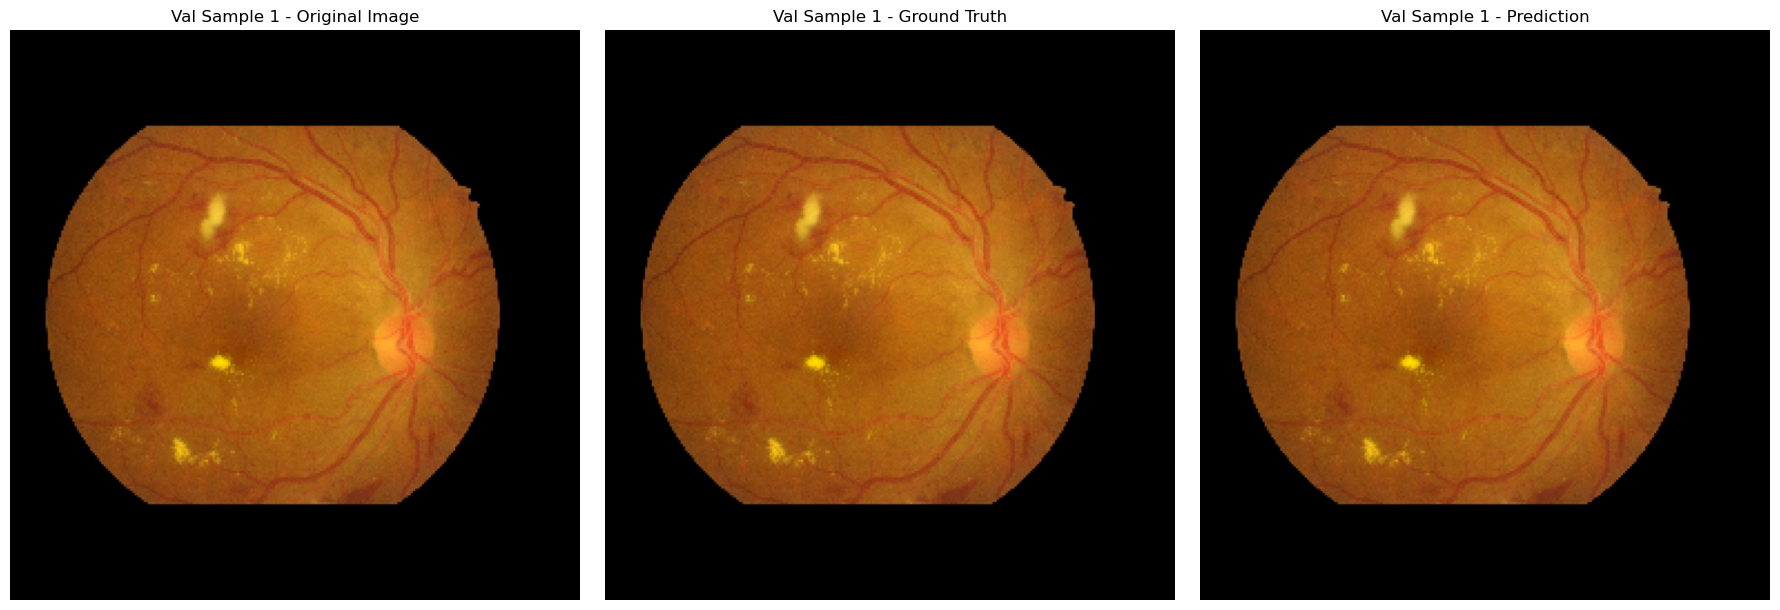

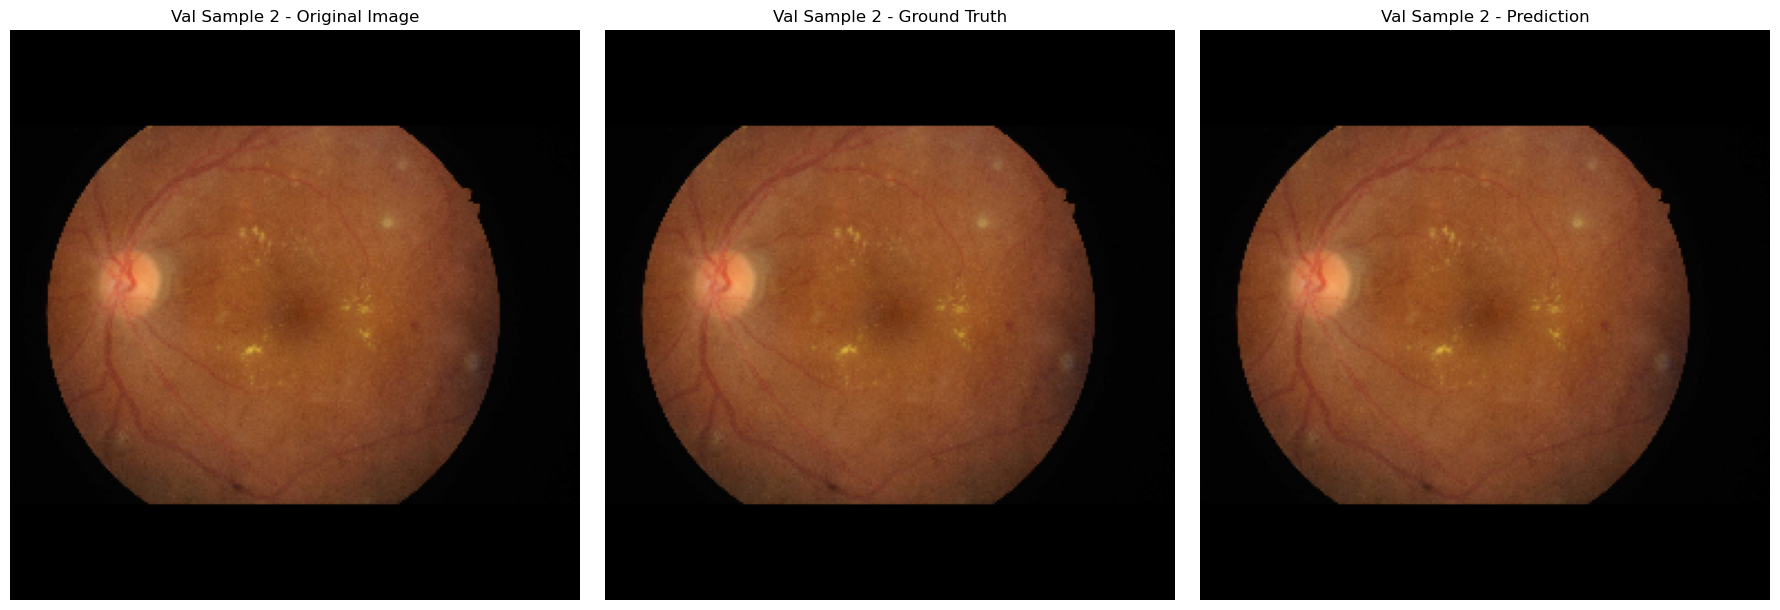

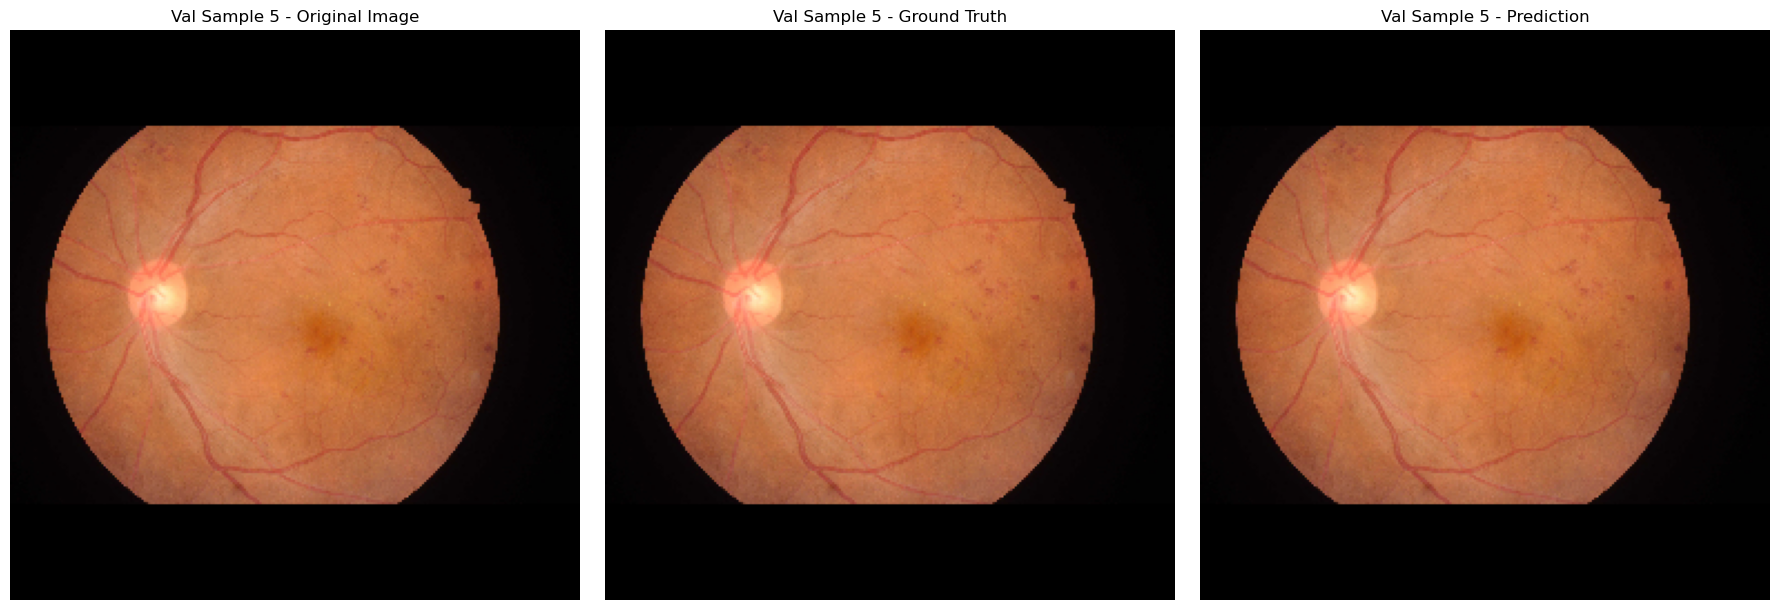

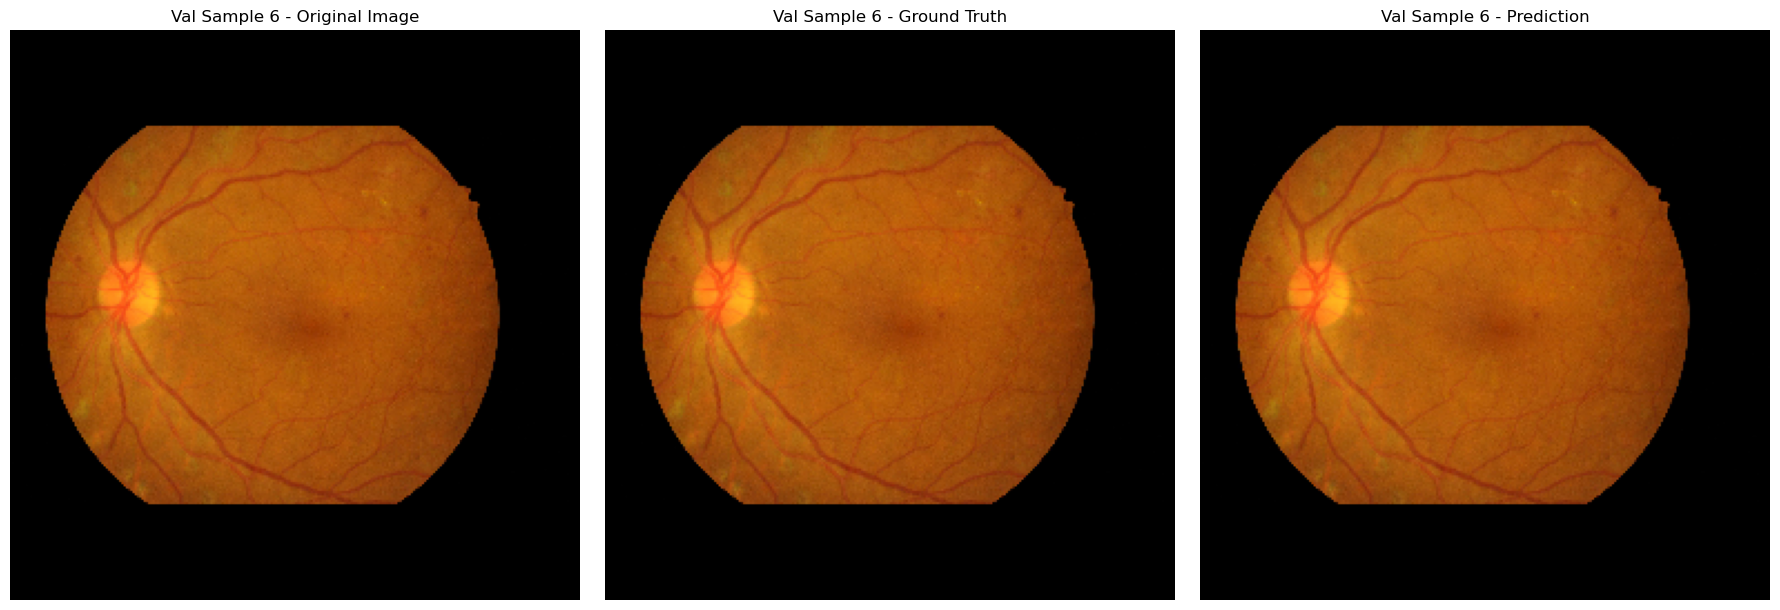

In [17]:
# Visualization: Compare predictions with ground truth
def visualize_prediction(image, mask_gt, mask_pred, lesion_types, title="Prediction"):
    """Visualize image with GT and predicted masks."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Convert image tensor to numpy
    if isinstance(image, torch.Tensor):
        img_np = image.cpu().numpy()
        if img_np.shape[0] == 3:
            img_np = img_np.transpose(1, 2, 0)
        # Denormalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = img_np * std + mean
        img_np = np.clip(img_np, 0, 1)
    else:
        img_np = image
    
    # Convert masks to numpy
    if isinstance(mask_gt, torch.Tensor):
        mask_gt_np = mask_gt.cpu().numpy()
    else:
        mask_gt_np = mask_gt
    
    if isinstance(mask_pred, torch.Tensor):
        mask_pred_np = mask_pred.cpu().numpy()
    else:
        mask_pred_np = mask_pred
    
    # Color coding
    colors = {
        'ma': [1, 0, 0],      # Red
        'he': [0, 1, 0],      # Green
        'ex_hard': [1, 1, 0], # Yellow
        'ex_soft': [0, 1, 1], # Cyan
        'od': [1, 0, 1]       # Magenta
    }
    
    # Original image
    axes[0].imshow(img_np)
    axes[0].set_title(f"{title} - Original Image")
    axes[0].axis('off')
    
    # Ground truth overlay
    overlay_gt = img_np.copy()
    for i, lesion_type in enumerate(lesion_types):
        if i < mask_gt_np.shape[0]:
            mask_channel = mask_gt_np[i]
            color = colors.get(lesion_type, [1, 1, 1])
            overlay_gt[mask_channel > 0.5] = np.array(color)
    
    axes[1].imshow(overlay_gt)
    axes[1].set_title(f"{title} - Ground Truth")
    axes[1].axis('off')
    
    # Prediction overlay
    overlay_pred = img_np.copy()
    for i, lesion_type in enumerate(lesion_types):
        if i < mask_pred_np.shape[0]:
            mask_channel = mask_pred_np[i]
            color = colors.get(lesion_type, [1, 1, 1])
            overlay_pred[mask_channel > 0.5] = np.array(color)
    
    axes[2].imshow(overlay_pred)
    axes[2].set_title(f"{title} - Prediction")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize a few examples
print("\nVisualizing predictions on validation set...")
model.eval()
lesion_types = list(IDRID_MASKS_DIRS.keys())

with torch.no_grad():
    for i, (images, masks) in enumerate(val_loader):
        if i >= 2:  # Show 2 batches
            break
        
        images = images.to(device)
        masks = masks.to(device)
        
        pred_logits = model(images)
        pred_masks = torch.sigmoid(pred_logits)
        
        # Visualize each image in batch
        for j in range(min(2, images.size(0))):  # Show 2 images per batch
            img = images[j].cpu()
            mask_gt = masks[j].cpu()
            mask_pred = pred_masks[j].cpu()
            
            visualize_prediction(
                img, mask_gt, mask_pred, 
                lesion_types, 
                title=f"Val Sample {i*BATCH_SIZE + j + 1}"
            )


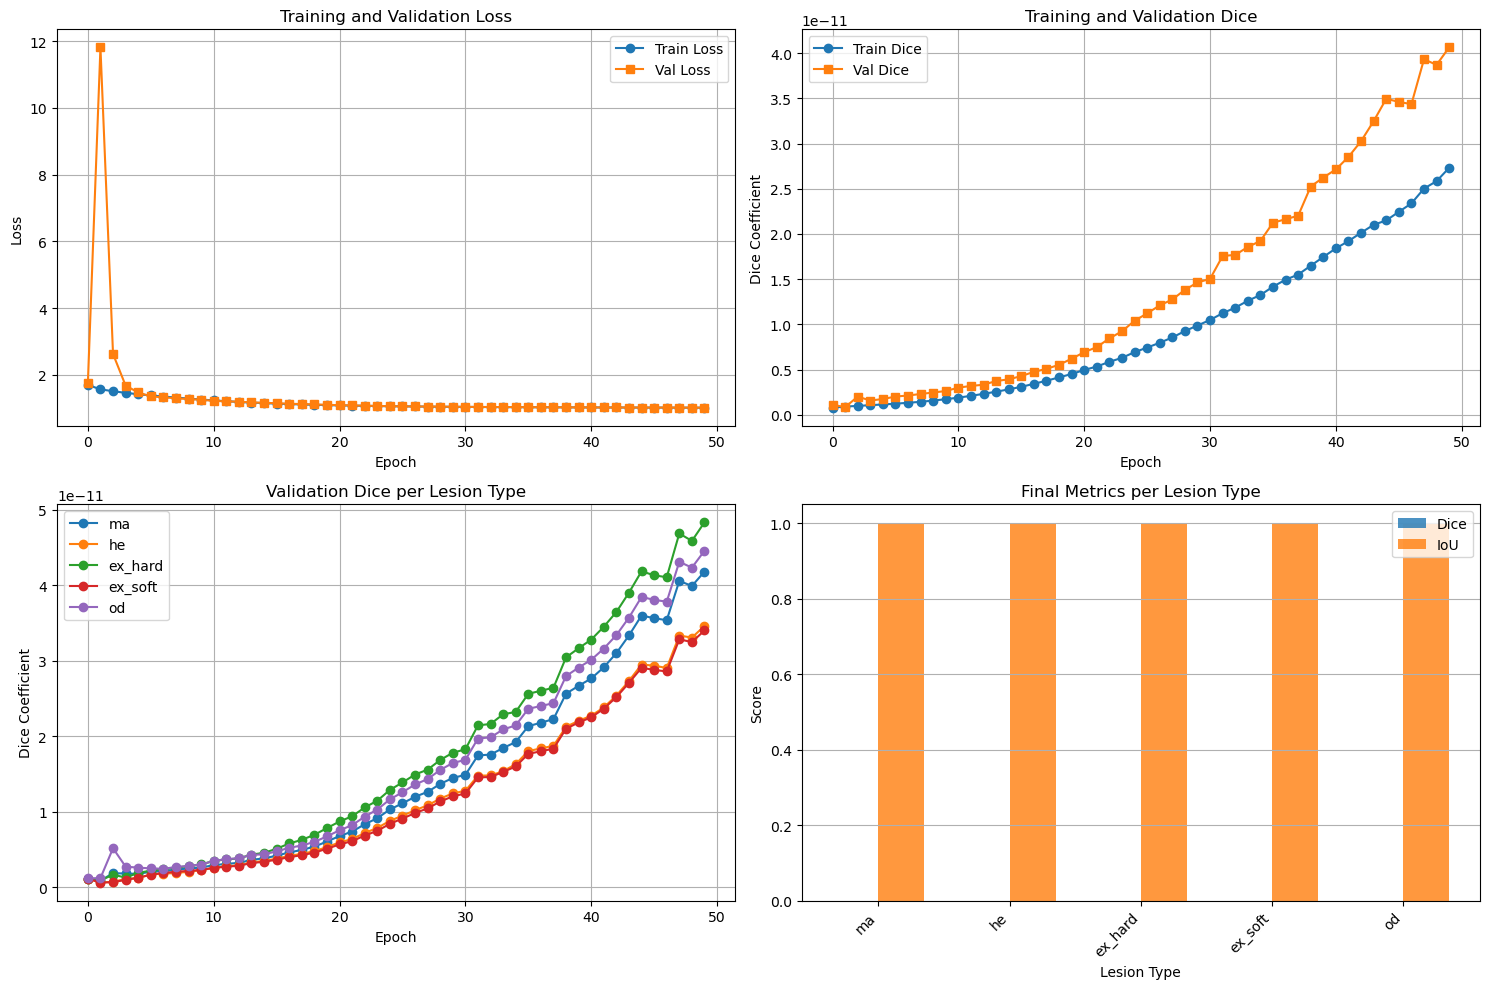

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
final_val_dice_ex_hard,▁
final_val_dice_ex_soft,▁
final_val_dice_he,▁
final_val_dice_ma,▁
final_val_dice_mean,▁
final_val_dice_od,▁
final_val_iou_ex_hard,▁
final_val_iou_ex_soft,▁
final_val_iou_he,▁
+13,...



✓ Training complete! W&B run finished.


In [18]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Dice
axes[0, 1].plot(history['train_dice'], label='Train Dice', marker='o')
axes[0, 1].plot(history['val_dice'], label='Val Dice', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Dice Coefficient')
axes[0, 1].set_title('Training and Validation Dice')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Per-class Dice (validation)
if len(history['val_dice_per_class']) > 0:
    val_dice_per_class_array = np.array(history['val_dice_per_class'])
    for i, lesion_type in enumerate(IDRID_MASKS_DIRS.keys()):
        axes[1, 0].plot(val_dice_per_class_array[:, i], label=lesion_type, marker='o')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Dice Coefficient')
    axes[1, 0].set_title('Validation Dice per Lesion Type')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

# Final per-class metrics bar chart
lesion_types = list(IDRID_MASKS_DIRS.keys())
x = np.arange(len(lesion_types))
width = 0.35

axes[1, 1].bar(x - width/2, final_dice_per_class, width, label='Dice', alpha=0.8)
axes[1, 1].bar(x + width/2, final_iou_per_class, width, label='IoU', alpha=0.8)
axes[1, 1].set_xlabel('Lesion Type')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Final Metrics per Lesion Type')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(lesion_types, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(True, axis='y')

plt.tight_layout()
plt.show()

# Finish W&B run
wandb.finish()
print("\n✓ Training complete! W&B run finished.")
